In [53]:
import torch
import datasets
import matplotlib.pyplot as plt

from model_loader import make_model, DEVICE

model = make_model(
    model_type="attn_unet",
    channels="KP"
)
model.load_state_dict(torch.load(
    # "official_darcy/final/fixed_physics_limited_attn_unet_darcy_1p0_final_state.pt",
    # "baseline_full/final/fixed_attn_unet_baseline_full_nodarcy_best_state.pt",
    "recent_analysis_unet/physics_tests/fixed/fixed_physics_limited_attn_unet_darcy_0p0_best_state.pt",
    map_location=DEVICE
))

model.eval()

AttnUnet(
  (c1): TwoConv(
    (seq): Sequential(
      (0): Conv2d(2, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (d1): Downsample(
    (conv): TwoConv(
      (seq): Sequential(
        (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (d2): Downsample(


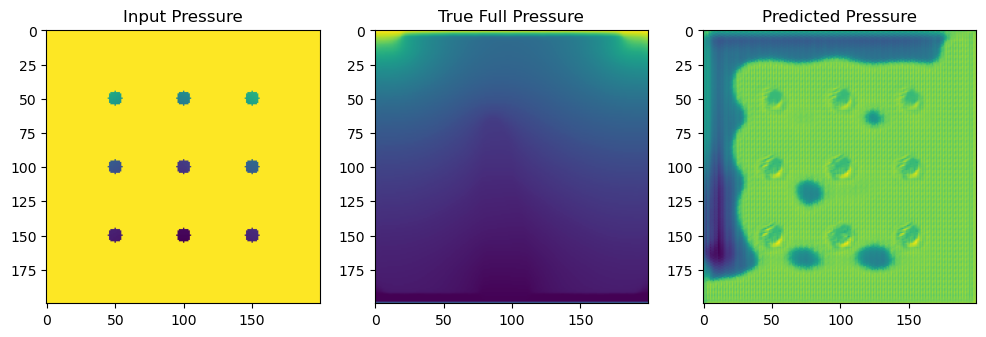

In [54]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import datasets
from model_loader import make_model, DEVICE, ChannelSelectDataset

val_sims = np.array([250])

base_dataset = datasets.FixedDenseDatasetFull(
    sims=val_sims,
    channels="KP"
)

dataset = ChannelSelectDataset(base_dataset, channels="KP")

feat, label = dataset[55]

with torch.no_grad():
    pred = model(feat.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[1].cpu())
plt.title("Input Pressure")

plt.subplot(1,3,2)
plt.imshow(label[1].cpu())
plt.title("True Full Pressure")

plt.subplot(1,3,3)
plt.imshow(pred[1])
plt.title("Predicted Pressure")

plt.show()

In [55]:
for name, x in [
    ("feat K", feat[0]),
    ("feat P", feat[1]),
    ("label K", label[0]),
    ("label P", label[1]),
    ("pred K", pred[0]),
    ("pred P", pred[1]),
]:
    print(name, x.min().item(), x.max().item(), x.mean().item())

feat K -1.0 0.0 -0.004216015804558992
feat P -0.8828125 0.0 -0.011534960940480232
label K -1.0 -0.0625 -0.17259491980075836
label P -1.0 0.9375 -0.5636628866195679
pred K -0.8091768026351929 0.2286999225616455 -0.3338708281517029
pred P -0.6652029752731323 0.44974949955940247 0.11285838484764099


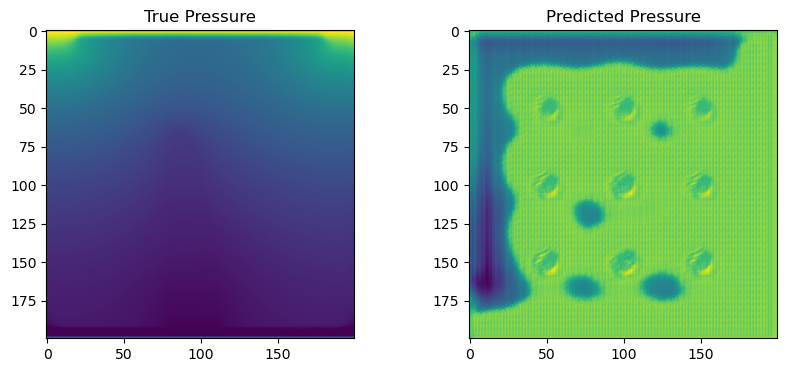

In [56]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(label[1].cpu())
plt.title("True Pressure")

plt.subplot(1, 2, 2)
plt.imshow(pred[1])
plt.title("Predicted Pressure")

plt.show()

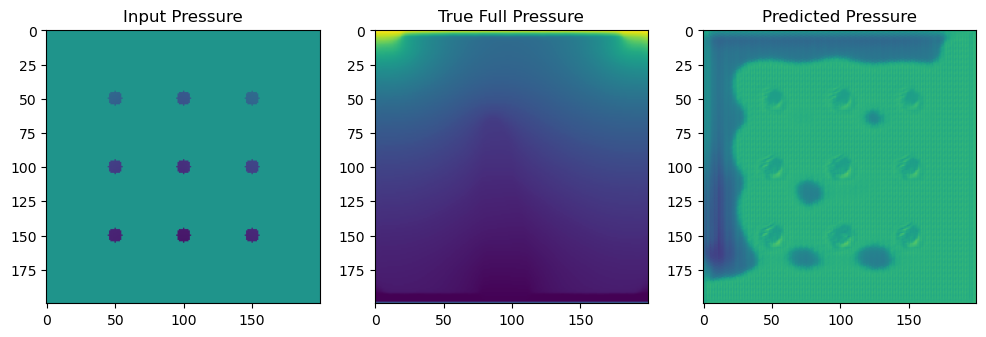

In [57]:
true_p = label[1].cpu()
pred_p = pred[1].cpu()

vmin = min(true_p.min().item(), pred_p.min().item())
vmax = max(true_p.max().item(), pred_p.max().item())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[1].cpu(), vmin=vmin, vmax=vmax)
plt.title("Input Pressure")

plt.subplot(1,3,2)
plt.imshow(true_p, vmin=vmin, vmax=vmax)
plt.title("True Full Pressure")

plt.subplot(1,3,3)
plt.imshow(pred_p, vmin=vmin, vmax=vmax)
plt.title("Predicted Pressure")

plt.show()

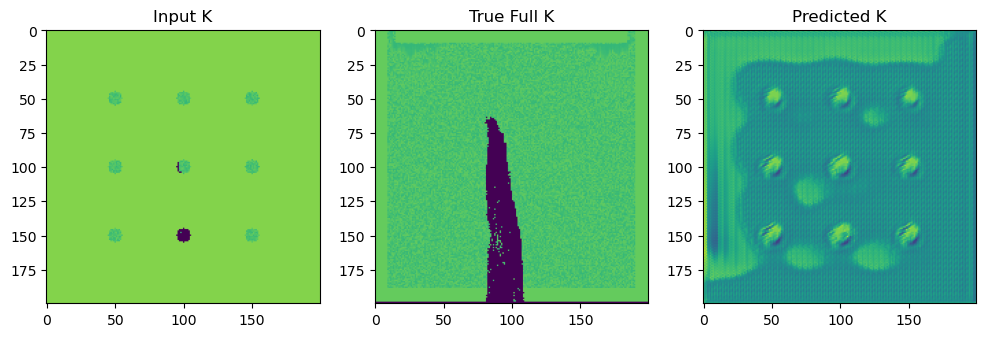

In [58]:
true_k = label[0].cpu()
pred_k = pred[0].cpu()

vmin = min(true_k.min().item(), pred_k.min().item())
vmax = max(true_k.max().item(), pred_k.max().item())

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(feat[0].cpu(), vmin=vmin, vmax=vmax)
plt.title("Input K")

plt.subplot(1,3,2)
plt.imshow(true_k, vmin=vmin, vmax=vmax)
plt.title("True Full K")

plt.subplot(1,3,3)
plt.imshow(pred_k, vmin=vmin, vmax=vmax)
plt.title("Predicted K")

plt.show()